In [1]:
# integration of Bessel function
import scipy.special as sp
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# define 0-th order Bessel function
def bessel_0(x):
    return sp.jv(0, x)

# define a sin function
def sin_func(x):
    return np.sin(x)

# function to integrate
def func_integrate(rho, a, b, c, r,z):
    return bessel_0(a*r*rho) * sin_func(b*z*(np.sqrt(1-c*rho**2)-1))

# integrate from rho = 0 to 1
from scipy.integrate import quad
wavelength = 0.45 # wavelength (nm); 380-760 nm, use 450 nm
NA = 1.45 # numerical aperture
n = 1.518 # refractive index of immersion oil
k = 2*np.pi/wavelength # k = 2*pi/lambda
a = k*NA # a = k*NA
b = k*n # b = k*n
c = (NA/n)**2 # c = (NA/n)^2

# # ---simulation---
# # for z = -10-10, r = 0-10
# # store x, z, integral
# PSF = pd.DataFrame(columns=['x', 'z', 'PSF'])
# for z in np.linspace(-5, 5, 301):
#     for r in np.linspace(0, 6.71/2*1.414, 301):
#         integral, _ = quad(func_integrate, 0, 1, args=(a, b, c, r, z))
#         x= r/np.sqrt(2)
#         PSF_new = pd.DataFrame({'x': [x], 'z': [z], 'PSF': [integral]})
#         PSF = pd.concat([PSF, PSF_new], axis=0)        
# # add -x
# PSF_minus = PSF.copy()
# PSF_minus['x'] = -PSF_minus['x']
# PSF = pd.concat([PSF, PSF_minus], axis=0)
# # ---simulation---

# load PSF
PSF = pd.read_csv('PSF_simulation_real_condition.csv')

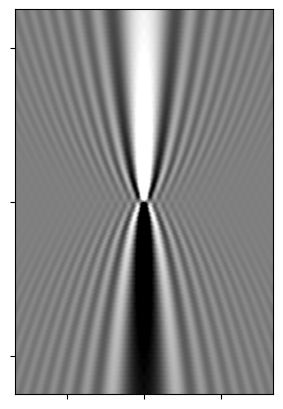

In [2]:
# show PSF
plt.figure(figsize=(5, 5))
# define contrast
min = -0.1
max = 0.1
# plot
plt.scatter(PSF['x'], -PSF['z'], c=1*PSF['PSF'], cmap='gray', s=0.1, vmin=min, vmax=max)
# plt.scatter(PSF_minus['x'], PSF_minus['z'], c=PSF_minus['PSF'], cmap='gray', s=0.1)
# plt.scatter(-PSF_minus['x'], PSF_minus['z'], c=PSF_minus['PSF'], cmap='gray', s=0.1)
# plt.xlabel('x ($\mu$m)', fontsize=12)
# plt.ylabel('z ($\mu$m)', fontsize=12)
# tick label
plt.xticks(fontsize=12)
plt.yticks([-4, 0, 4], fontsize=12)
# remove tick label, keep the tick
plt.tick_params(labelbottom=False, labelleft=False)
plt.ylim(-5, 5)
plt.xlim(-6.71/2, 6.71/2)
# invert y axis
# plt.gca().invert_yaxis()
# equal aspect ratio
plt.gca().set_aspect('equal', adjustable='box')
# save
# plt.savefig('simulated_PSF_to_show_scale.png', dpi=300, bbox_inches='tight')

# # save
# plt.axis('off')
# plt.savefig('simulated_PSF.png', dpi=300, bbox_inches='tight')


In [3]:
# save PSF
# PSF.to_csv('PSF_simulation_real_condition.csv', index=False)

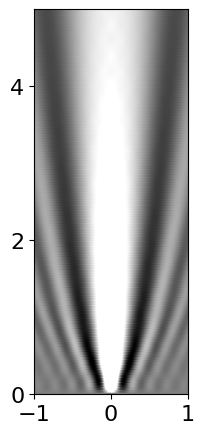

In [4]:
PSF_threshold = PSF.copy()
min = -0.1
max = 0.1
# plot
plt.figure(figsize=(5, 5))
plt.scatter(PSF_threshold['x'], -PSF_threshold['z'], c=PSF_threshold['PSF'], cmap='gray', s=1.5, vmin=min, vmax=max)
plt.ylim(0, 5)
plt.xlim(-1, 1)
# tick label
plt.xticks([-1, 0, 1], fontsize=16)
plt.yticks([0, 2, 4], fontsize=16)
# equal aspect ratio
plt.gca().set_aspect('equal', adjustable='box')
# plt.savefig('simulated_PSF_before_threshold.png', dpi=300, bbox_inches='tight')

7


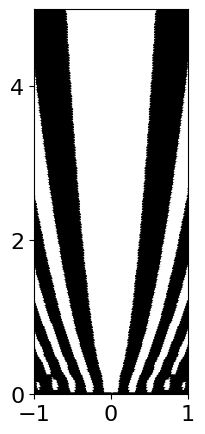

In [5]:
# threshold 
# get background intensity (z in +-1, x in 3-3.5)
background = PSF[(PSF['z'] > -1) & (PSF['z'] < 1) & (PSF['x'] > 3) & (PSF['x'] < 3.5)]['PSF']
n_std = 148/20*1
n_std_name = int(n_std/148*150)
print(n_std_name)
threshold = background.mean()+n_std*background.std()
# threshold = 0.09
PSF_threshold = PSF.copy()
PSF_threshold['PSF'] = PSF_threshold['PSF'].apply(lambda x: 1 if x>threshold else 0)

# plot
plt.figure(figsize=(5, 5))
plt.scatter(PSF_threshold['x'], -PSF_threshold['z'], c=PSF_threshold['PSF'], cmap='gray', s=2.5)
plt.ylim(0, 5)
plt.xlim(-1, 1)
# tick label
plt.xticks([-1, 0, 1], fontsize=16)
plt.yticks([0, 2, 4], fontsize=16)
# equal aspect ratio
plt.gca().set_aspect('equal', adjustable='box')
# save
# plt.savefig('simulated_PSF_bright_threshold{}.png'.format(threshold), dpi=300, bbox_inches='tight')
# plt.savefig('simulated_PSF_bright_threshold_{}std.png'.format(n_std_name), dpi=300, bbox_inches='tight')
